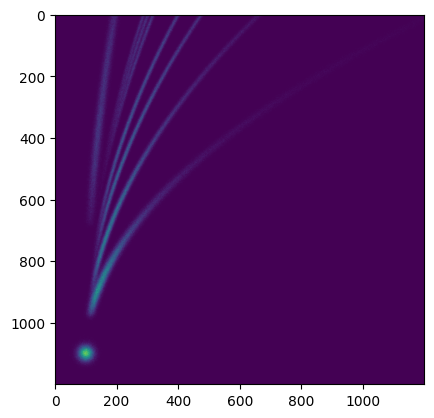

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

INPUT_IMAGE = "detector_image.png"
OUTPUT_IMAGE = "noisy_detector_image.png"

img = Image.open(INPUT_IMAGE).convert('L')
img_array = np.array(img, dtype=np.float32)

plt.imshow(img_array)

In [ ]:
from utils.noise import (
    apply_white_spots, 
    apply_black_spots, 
    apply_vertical_lines, 
    apply_perlin_darkening, 
    apply_perlin_whitening, 
    apply_general_noise
)

# Apply noise sequentially
noisy_array = apply_white_spots(img_array)
noisy_array = apply_black_spots(noisy_array)
noisy_array = apply_vertical_lines(noisy_array)
noisy_array = apply_perlin_darkening(noisy_array)
noisy_array = apply_perlin_whitening(noisy_array)
noisy_array = apply_general_noise(noisy_array)

In [4]:
# Clip values to valid 8-bit range and cast
final_array = np.clip(noisy_array, 0, 255).astype(np.uint8)

# Save
out_img = Image.fromarray(final_array, mode='L')

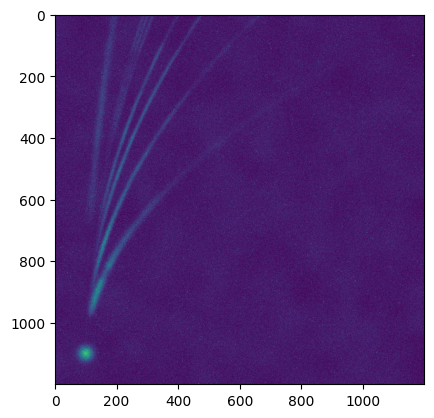

In [5]:
plt.imshow(out_img)

In [6]:
out_img.save(OUTPUT_IMAGE)
print(f"Noise applied successfully. Saved as {OUTPUT_IMAGE}")

Noise applied successfully. Saved as noisy_detector_image.png
